In [1]:
%matplotlib inline
from sklearn.datasets import load_digits
digits = load_digits()
print("Image Data Shape", digits.data.shape)
print("Label Data Shape", digits.target.shape)

Image Data Shape (1797, 64)
Label Data Shape (1797,)


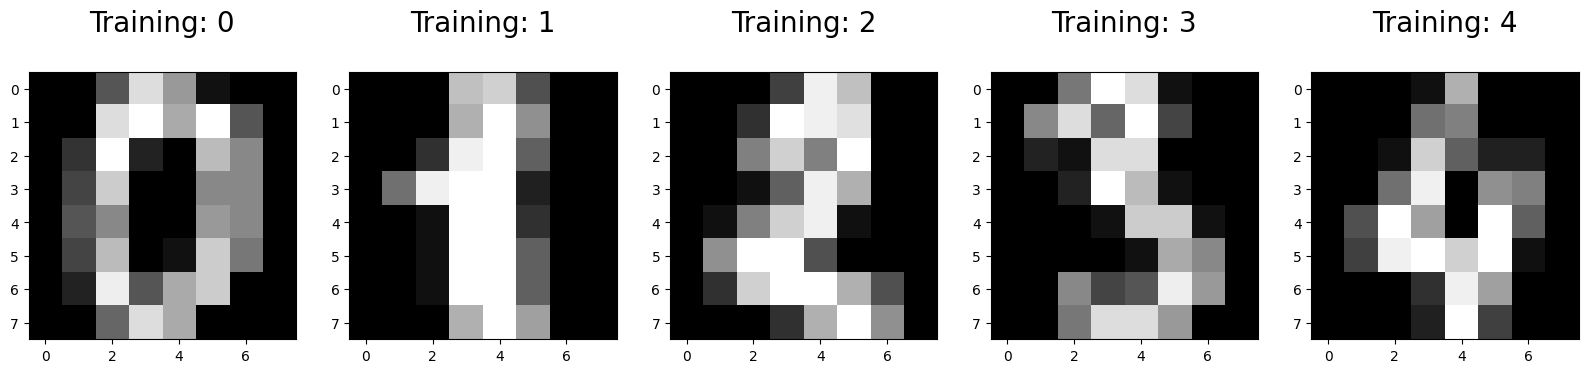

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))

# zip(data, target): 이미지 숫자 배열과 실제 정답을 한 쌍으로 묶는다.
# enumerate: 몇 번째 반복인지 index(0, 1, 2...)를 생성한다.
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])):
  plt.subplot(1, 5, index+1)

  # np.reshape(image, (8, 8)): 일렬로 펴진 64개 숫자를 8x8 사각형으로 다시 접는다.
  # cmap=plt.cm.gray: '화색조 색상 지도'를 사용하여 흑백 사진처럼 출력
  plt.imshow(np.reshape(image, (8, 8)), cmap=plt.cm.gray)
  plt.title('Training: %i\n' % label, fontsize=20)

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target,
                                                    test_size=0.25, random_state=0)

from sklearn.linear_model import LogisticRegression
# 원래 이진 분류용이지만, 여기서는 0~9까지 10개의 숫자를 분류하는 다중 분류로 진행
logisticRegr = LogisticRegression(max_iter=2000)
logisticRegr.fit(x_train, y_train)

LogisticRegression(max_iter=2000)

In [14]:
logisticRegr.predict(x_test[0].reshape(1, -1))
logisticRegr.predict(x_test[0:10])

array([2, 8, 2, 6, 6, 7, 1, 9, 8, 5])

In [15]:
predictions = logisticRegr.predict(x_test)
score = logisticRegr.score(x_test, y_test)
print(score)

0.9533333333333334


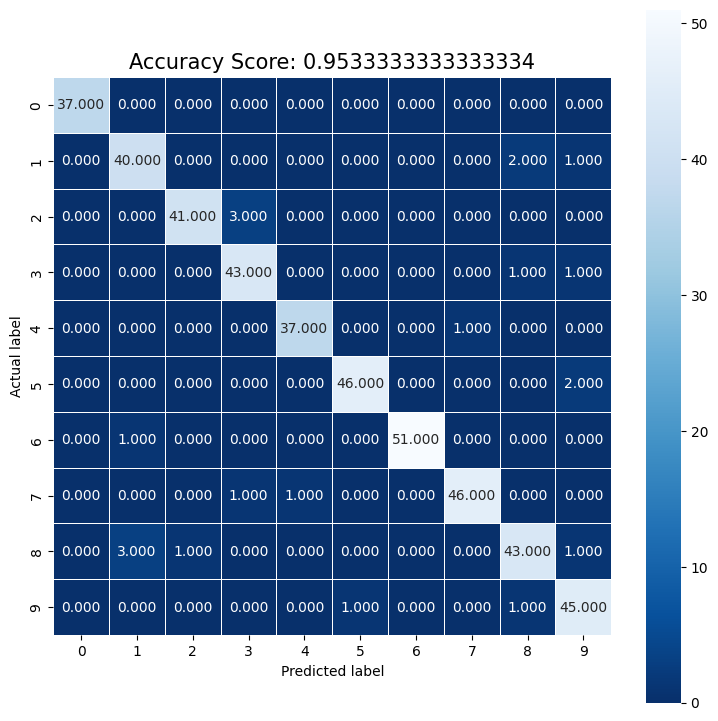

In [16]:
import numpy as np
import seaborn as sns
from sklearn import metrics

# 혼동 행렬 생성: 실제값(y_test)과 모델의 예측값(predictions)을 비교하여 행렬 형태로 변
cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(9, 9))

# annot=True: 각 셀에 숫자 표
# cmap='Blues_r': 파란색 계열의 색상 지도를 사용하며, _r이 붙어 있어 값이 클수록 파란색으로 표시
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size=15);
plt.show();